In [1]:
import re
from pathlib import Path
import numpy as np
import arviz as az
import seaborn as sns
import ringdown as rd
from ringdown.result import Result
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

/home/selmavangstein/miniconda3/envs/ringdown/lib/python3.11/site-packages/ringdown/data.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
# Configuration
FIT_DIR = Path("./fitresults/chaintests")
VAR_NAMES_CORNER = ['m', 'chi']
VAR_NAMES_TRACE = ['m', 'chi', 'a']
PLOT_DIR = Path("./fitresults_plots/chaintests")

# Parameters from your configuration
num_chains = [4, 8]
num_samples = [2000, 4000]
num_runs = 2

nrows = len(num_chains) * len(num_samples)
ncols = num_runs

In [3]:
# Parse filenames and load all results
pattern = re.compile(r".*chains_(\d+)_samples_(\d+)_run_(\d+)\.nc$", re.IGNORECASE)
files = {}
results = {}  # Store loaded results

for p in FIT_DIR.glob("*.nc"):
    m = pattern.match(p.name)
    if not m:
        continue
    chains = int(m.group(1))
    samples = int(m.group(2))
    run = int(m.group(3))
    key = (chains, samples, run)
    files[key] = p
    
    # Load the result immediately
    try:
        results[key] = Result.from_netcdf(p)
        print(f"Loaded: chains={chains}, samples={samples}, run={run}")
    except Exception as e:
        print(f"Failed to load chains={chains}, samples={samples}, run={run}: {e}")

if not results:
    raise FileNotFoundError(f"No results could be loaded from {FIT_DIR}")

print(f"\nLoaded {len(results)} results total")
print(f"Available keys: {list(results.keys())}")

# You can now access any result like:
# results[(4, 2000, 0)] for chains=4, samples=2000, run=0

Loaded: chains=8, samples=2000, run=1
Loaded: chains=8, samples=4000, run=0
Loaded: chains=4, samples=2000, run=0
Loaded: chains=4, samples=2000, run=1
Loaded: chains=4, samples=4000, run=0
Loaded: chains=8, samples=2000, run=0
Loaded: chains=8, samples=4000, run=1
Loaded: chains=4, samples=4000, run=1

Loaded 8 results total
Available keys: [(8, 2000, 1), (8, 4000, 0), (4, 2000, 0), (4, 2000, 1), (4, 4000, 0), (8, 2000, 0), (8, 4000, 1), (4, 4000, 1)]


In [4]:
# create plotting function
def create_plot_grid(plot_func, title, save_name):
    """Helper function to create a grid of plots"""
    fig_main, axs_main = plt.subplots(nrows=nrows, ncols=ncols,
                                       figsize=(6 * ncols, 5 * nrows))
    axs_main = np.atleast_2d(axs_main).reshape(nrows, ncols)
    
    row_idx = 0
    for nc in num_chains:
        for ns in num_samples:
            for run_idx, run in enumerate(range(num_runs)):
                ax_main = axs_main[row_idx, run_idx]
                key = (nc, ns, run)
                
                if key not in results:
                    ax_main.text(0.5, 0.5, f"Missing\nchains={nc}\nsamples={ns}\nrun={run}", 
                               ha='center', va='center', fontsize=12)
                    ax_main.axis('off')
                    continue

                try:
                    res = results[key]  # Get pre-loaded result
                    
                    # Create the plot
                    temp_fig = plot_func(res, nc, ns, run)
                    
                    # Convert to image
                    buf = BytesIO()
                    temp_fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
                    buf.seek(0)
                    plt.close(temp_fig)
                    
                    img = Image.open(buf)
                    ax_main.imshow(np.array(img))
                    ax_main.axis('off')
                    
                except Exception as e:
                    ax_main.text(0.5, 0.5, f"Error\n{str(e)[:100]}", 
                               ha='center', va='center', fontsize=10)
                    ax_main.axis('off')
                    print(f"Error for chains={nc}, samples={ns}, run={run}: {e}")
            
            row_idx += 1
    
    # Add row labels
    row_idx = 0
    for nc in num_chains:
        for ns in num_samples:
            fig_main.text(0.01, 1 - (row_idx + 0.5) / nrows, 
                         f"chains={nc}\nsamples={ns}", 
                         ha='left', va='center', fontsize=12, weight='bold',
                         transform=fig_main.transFigure, rotation=0)
            row_idx += 1
    
    # Add column labels
    for run_idx in range(num_runs):
        fig_main.text((run_idx + 0.5) / ncols, 0.98, f"Run {run_idx}", 
                     ha='center', va='top', fontsize=14, weight='bold',
                     transform=fig_main.transFigure)
    
    plt.suptitle(title, fontsize=16, y=0.995)
    plt.tight_layout(rect=[0.05, 0, 1, 0.97])
    return fig_main  # Return the figure

In [5]:
# Define plotting functions
def plot_corner(res, nc, ns, run):
    axes = az.plot_pair(res, var_names=VAR_NAMES_CORNER, marginals=True, 
                       kind='kde', figsize=(5, 5))
    fig = plt.gcf()
    fig.suptitle(f"chains={nc}, samples={ns}, run={run}", y=1.02)
    return fig

def plot_amplitude(res, nc, ns, run):
    df = res.get_parameter_dataframe()
    g = sns.jointplot(x=df['a_220'], y=df['a_221'], kind='kde', fill=True)
    g.ax_joint.set_xlabel('$A_{220}$')
    g.ax_joint.set_ylabel('$A_{221}$')
    g.fig.suptitle(f"chains={nc}, samples={ns}, run={run}", y=1.02)
    return g.fig

def plot_freq_damp(res, nc, ns, run):
    df = res.get_mode_parameter_dataframe(500, latex=True)
    key_map = res.get_parameter_key_map(modes=False)
    
    pg = sns.PairGrid(df, vars=[key_map[k] for k in ['f', 'g']],
                     diag_sharey=False, hue='mode')
    pg.map_diag(sns.kdeplot)
    pg.map_upper(sns.scatterplot)
    pg.map_lower(rd.utils.kdeplot, levels=[0.9, 0.5, 0.1])
    pg.add_legend()
    pg.fig.suptitle(f"chains={nc}, samples={ns}, run={run}", y=1.02)
    return pg.fig

def plot_trace(res, nc, ns, run):
    axes = az.plot_trace(res, var_names=VAR_NAMES_TRACE, figsize=(10, 8))
    fig = plt.gcf()
    fig.suptitle(f"chains={nc}, samples={ns}, run={run}", y=0.995, fontsize=12)
    plt.tight_layout()
    return fig

def plot_area(res, nc, ns, run):
    m_post = np.array(res.posterior['m']).flatten()
    chi_post = np.array(res.posterior['chi']).flatten()
    area = 8*np.pi*m_post**2*(1+np.sqrt(1-chi_post**2))
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(area, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f"chains={nc}, samples={ns}, run={run}")
    ax.set_xlabel(r'Area $A$')
    ax.set_ylabel('Counts')
    plt.tight_layout()
    return fig


Creating plots...
Saved fig to fitresults_plots/chaintests/corner_plots_chains.png
Saved fig to fitresults_plots/chaintests/amplitude_plots_chains.png
Saved fig to fitresults_plots/chaintests/freq_damp_plots_chains.png
Saved fig to fitresults_plots/chaintests/trace_plots_chains.png
Saved fig to fitresults_plots/chaintests/area_plots_chains.png

All plots completed!


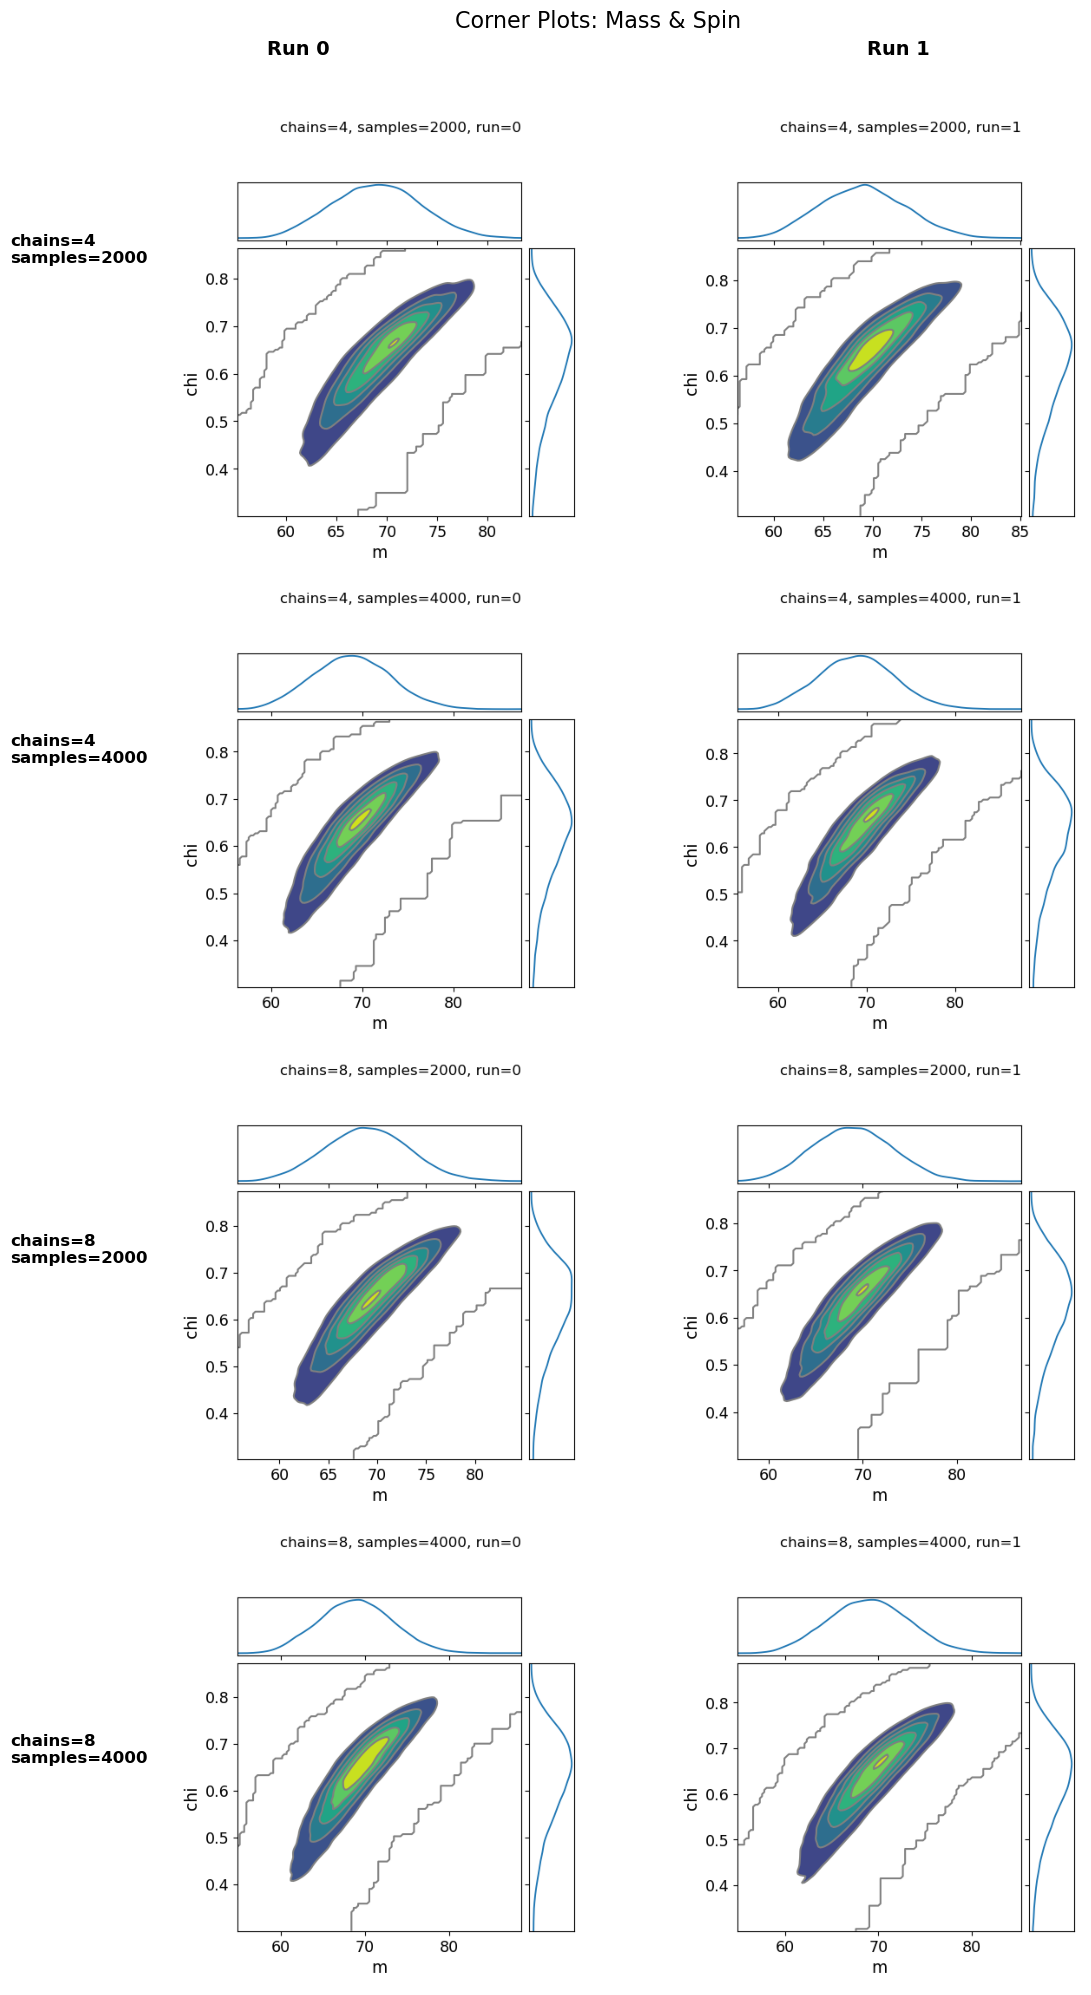

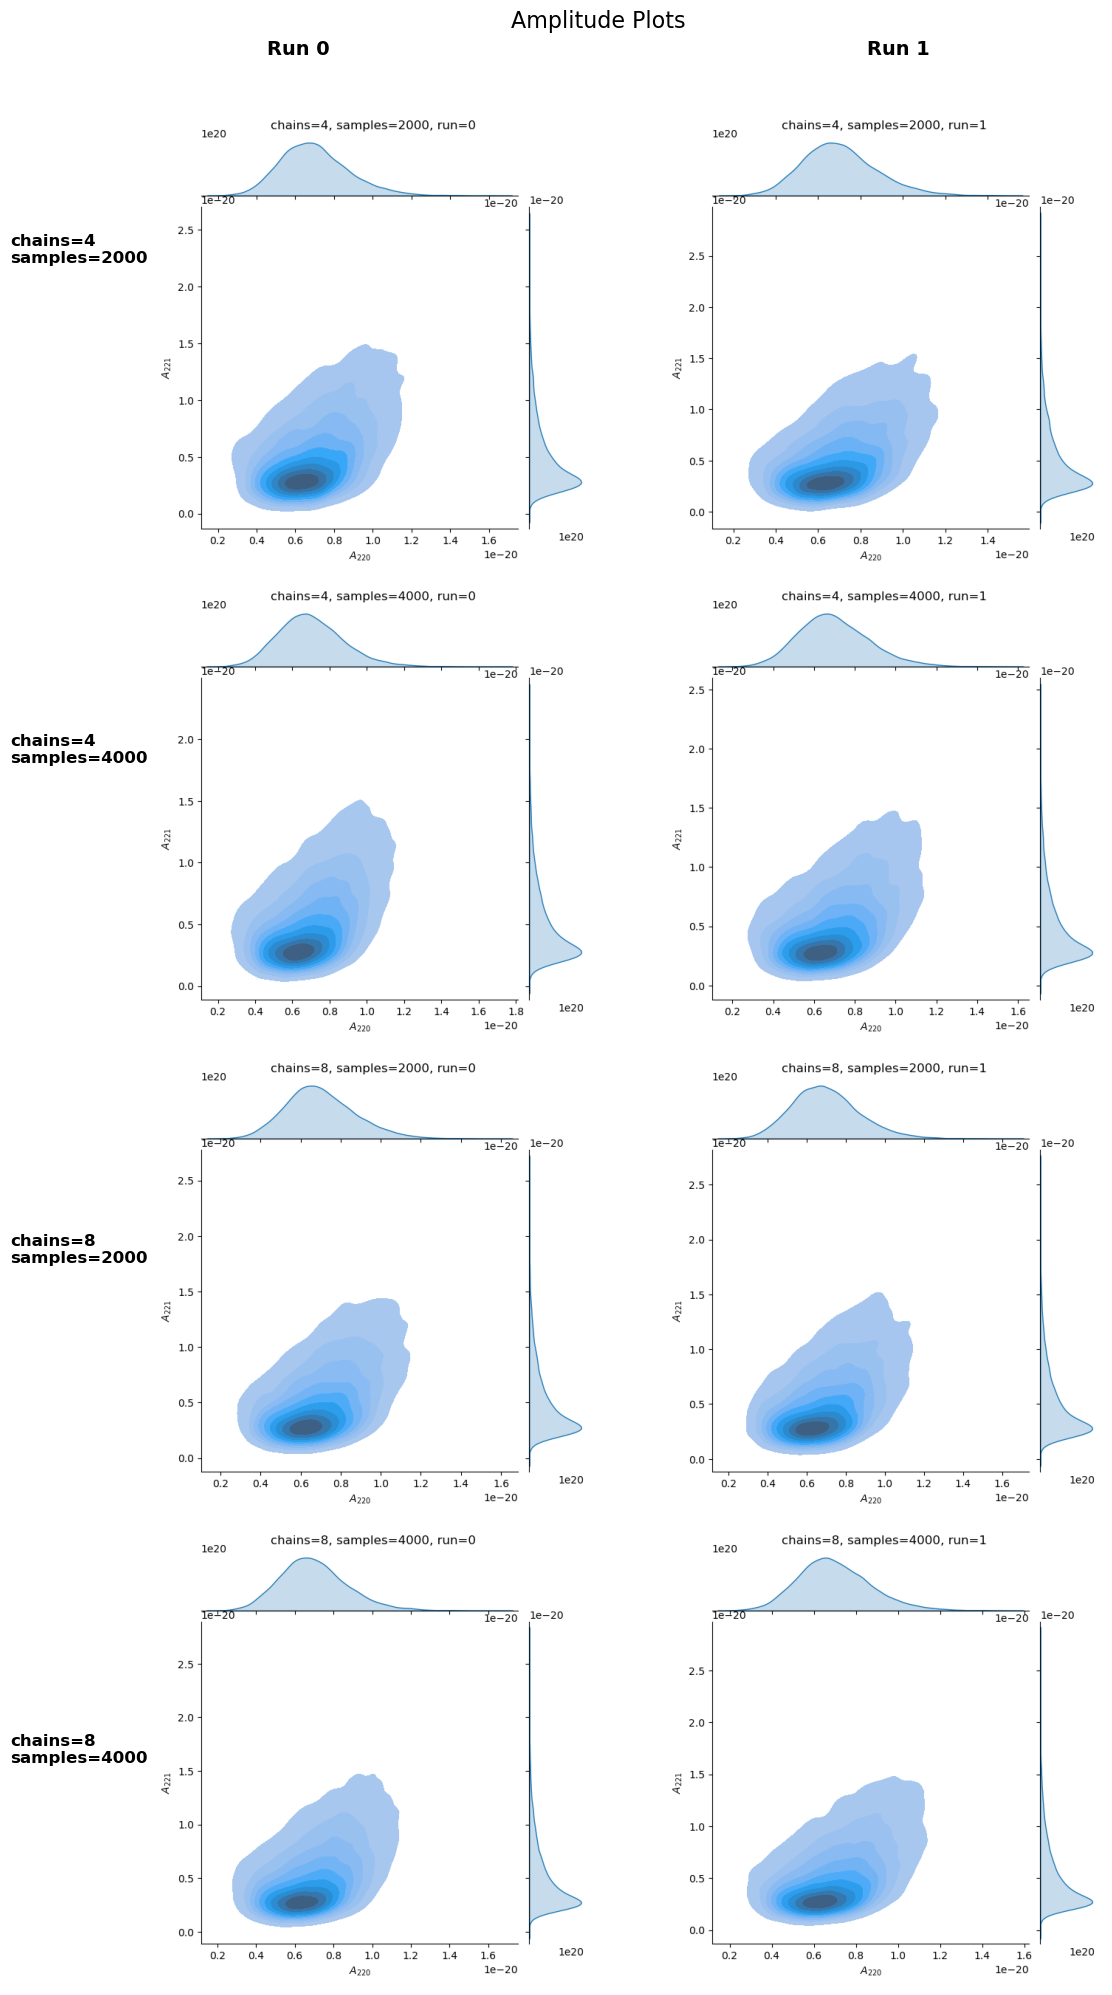

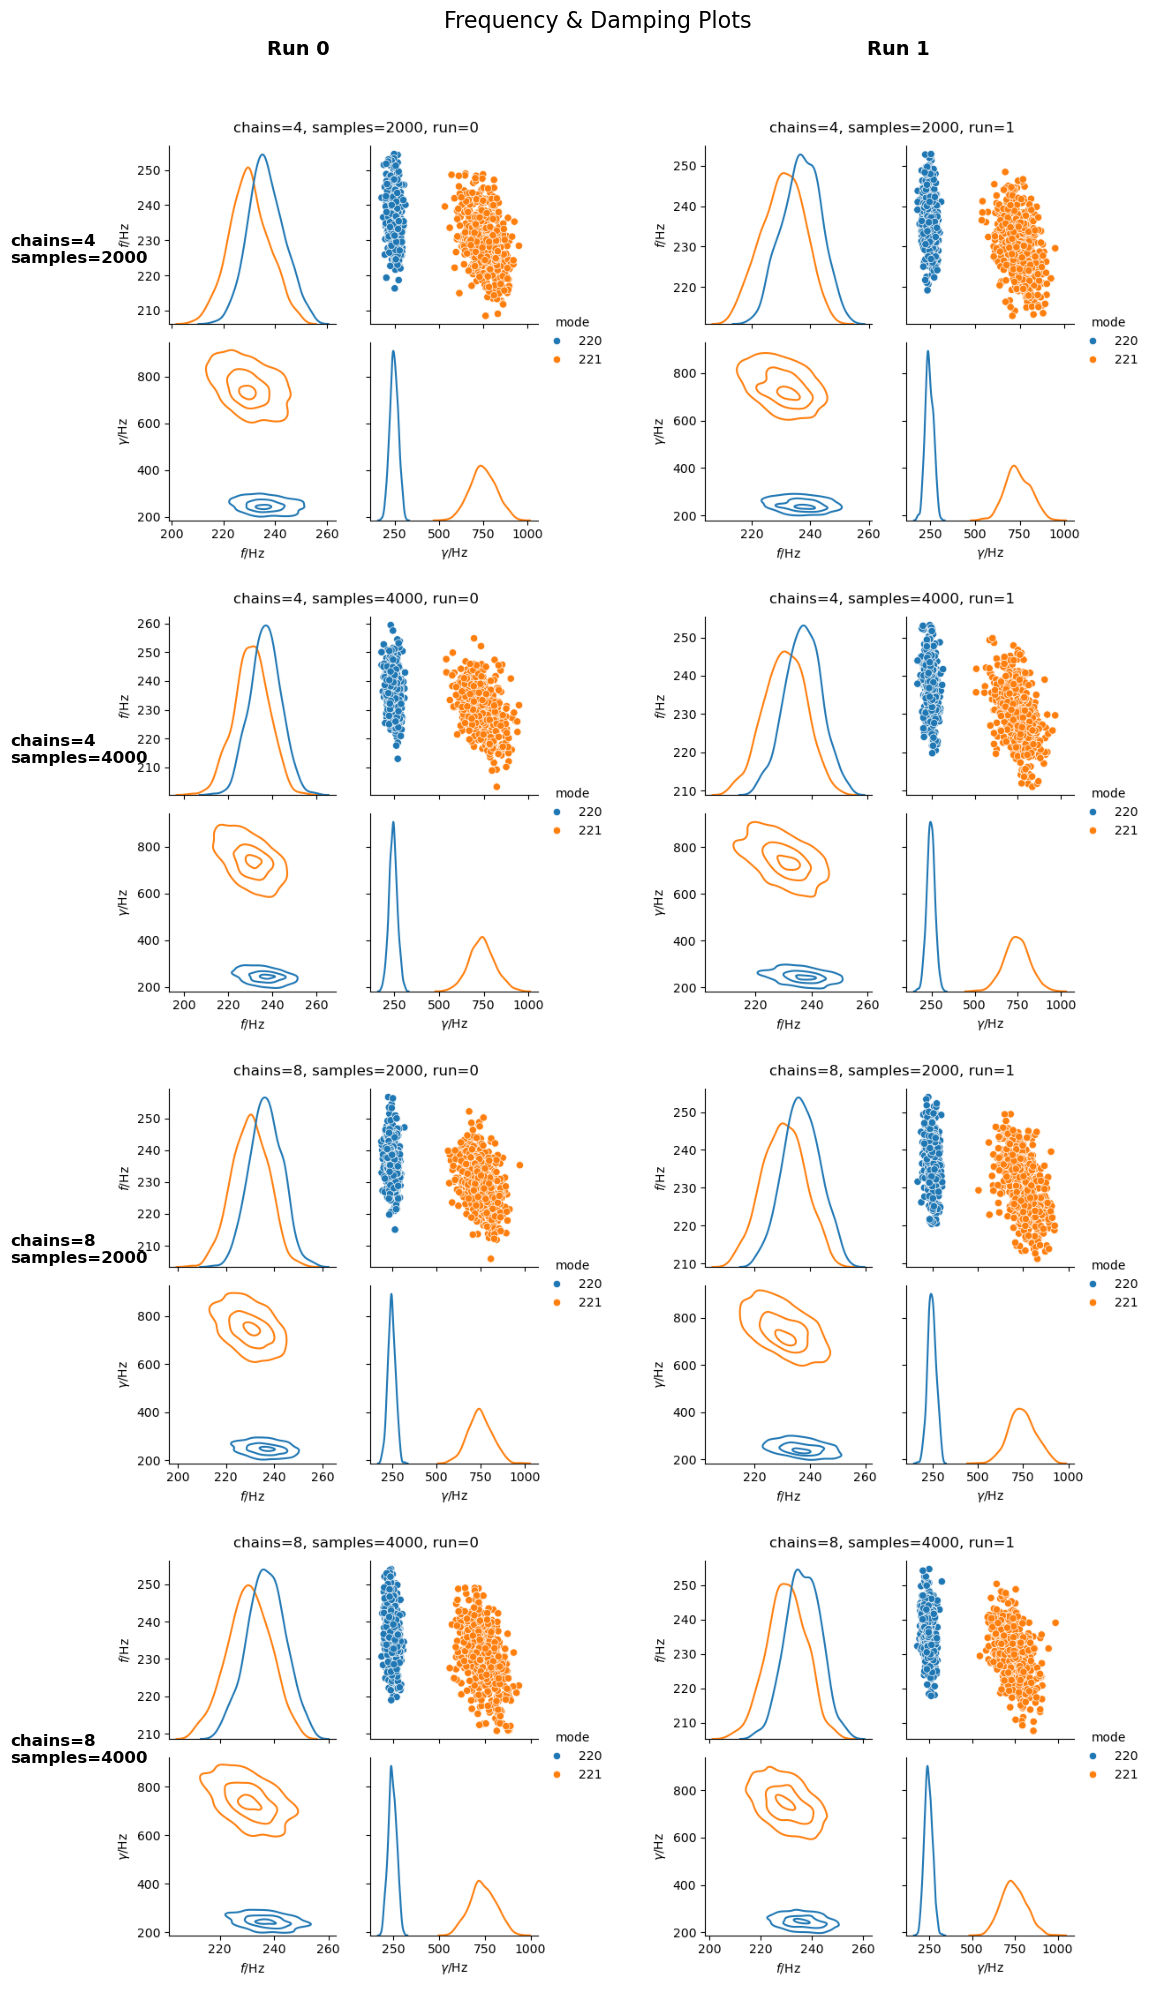

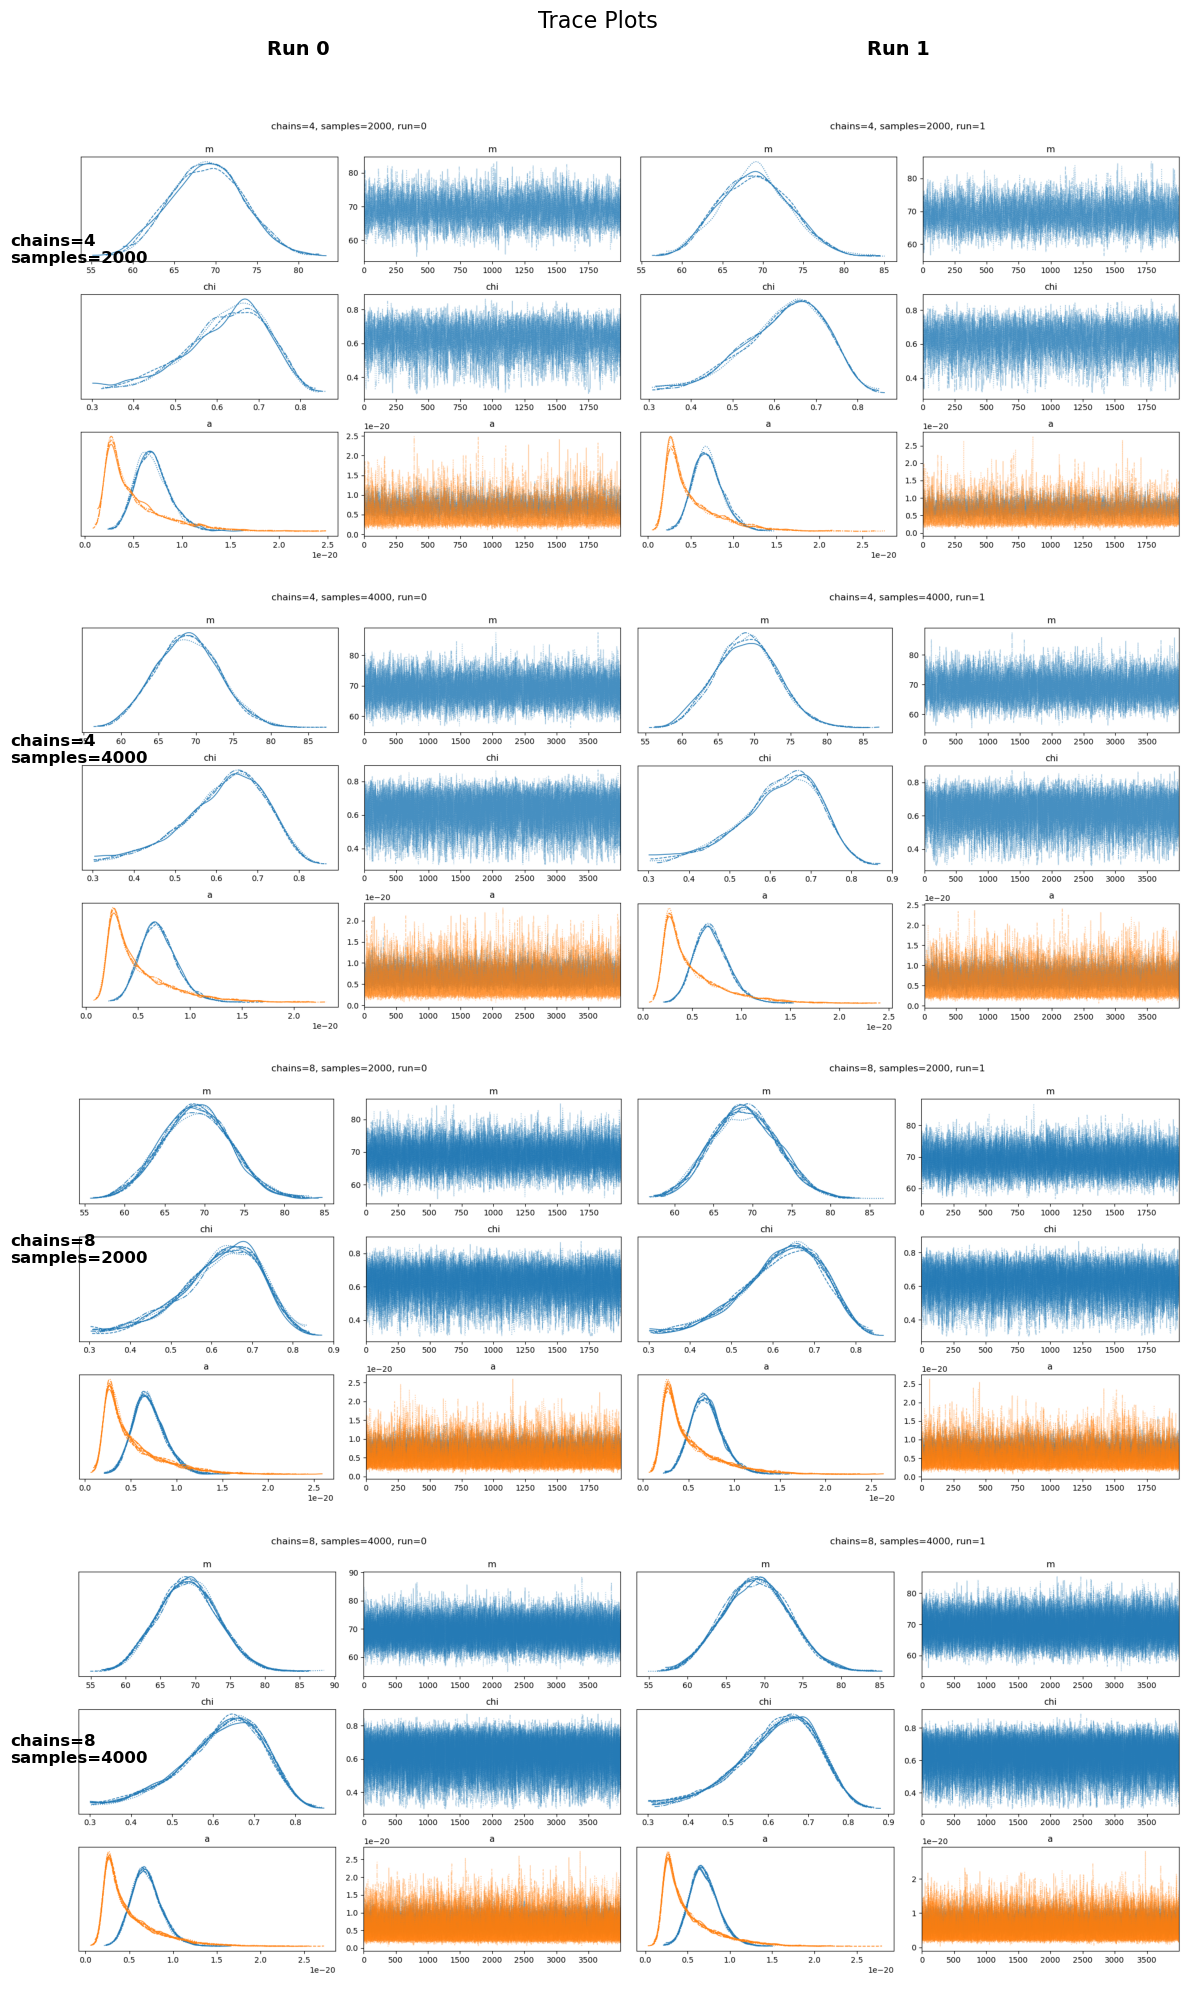

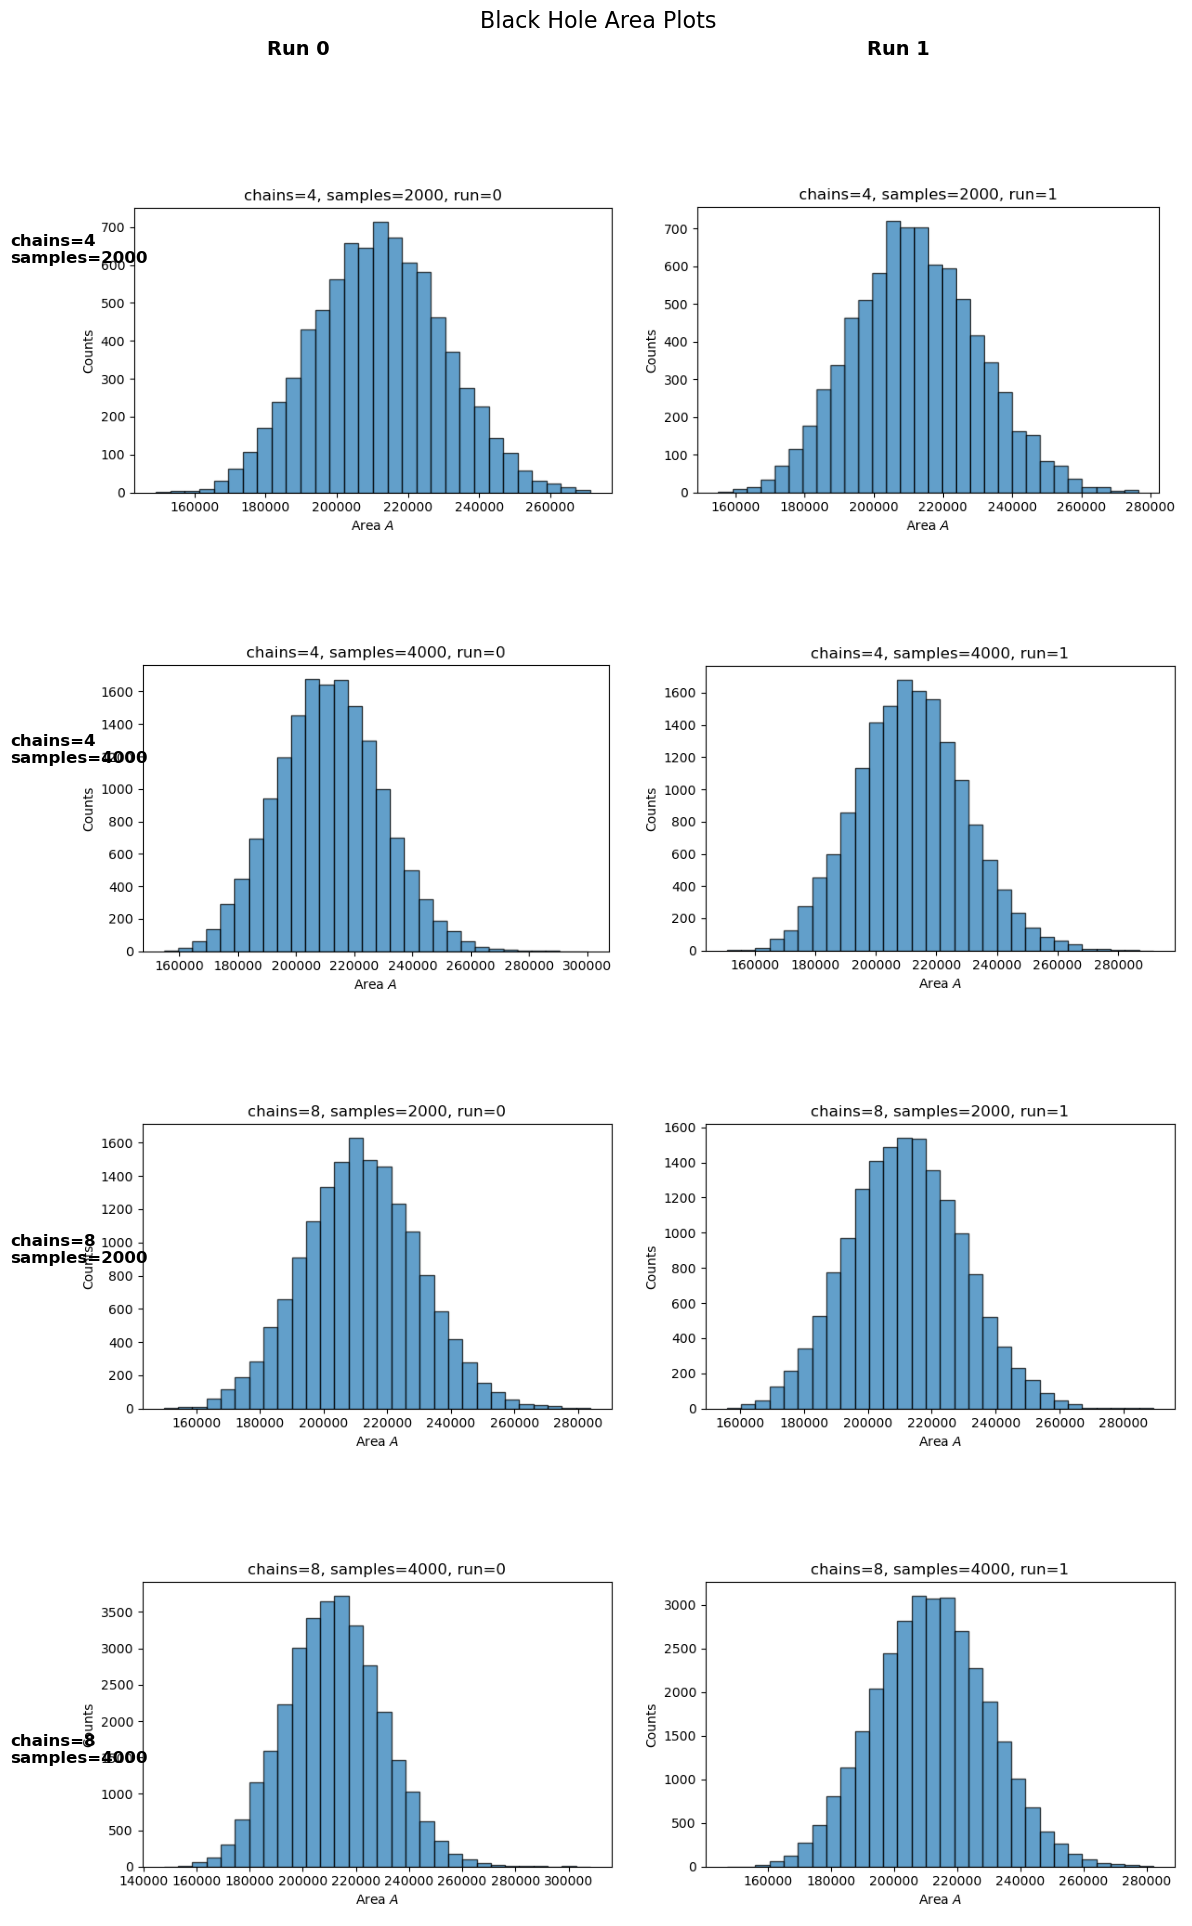

In [6]:
# Create all plots and store the figure objects
print("\nCreating plots...")

fig_corner = create_plot_grid(plot_corner, "Corner Plots: Mass & Spin", "corner_plots_chains.png");
fig_corner.savefig(PLOT_DIR / "corner_plots_chains.png", dpi=150, bbox_inches='tight')
print(f"Saved fig to {PLOT_DIR}/corner_plots_chains.png")

fig_amplitude = create_plot_grid(plot_amplitude, "Amplitude Plots", "amplitude_plots_chains.png");
fig_amplitude.savefig(PLOT_DIR / "amplitude_plots_chains.png", dpi=150, bbox_inches='tight')
print(f"Saved fig to {PLOT_DIR}/amplitude_plots_chains.png")

fig_freq_damp = create_plot_grid(plot_freq_damp, "Frequency & Damping Plots", "freq_damp_plots_chains.png");
fig_freq_damp.savefig(PLOT_DIR / "freq_damp_plots_chains.png", dpi=150, bbox_inches='tight')
print(f"Saved fig to {PLOT_DIR}/freq_damp_plots_chains.png")

fig_trace = create_plot_grid(plot_trace, "Trace Plots", "trace_plots_chains.png");
fig_trace.savefig(PLOT_DIR / "trace_plots_chains.png", dpi=150, bbox_inches='tight')
print(f"Saved fig to {PLOT_DIR}/trace_plots_chains.png")

fig_area = create_plot_grid(plot_area, "Black Hole Area Plots", "area_plots_chains.png");
fig_area.savefig(PLOT_DIR / "area_plots_chains.png", dpi=150, bbox_inches='tight')
print(f"Saved fig to {PLOT_DIR}/area_plots_chains.png")

print("\nAll plots completed!")

In [7]:
import pandas as pd

# Create a list to store all statistics
stats_list = []

for key, res in results.items():
    chains, samples, run = key
    summary = az.summary(res, var_names=['a', 'm', 'chi', 'f', 'g'])
    mean_values = summary['mean'].to_dict()
    mean_values.update({'chains': chains, 'samples': samples, 'run': run})
    stats_list.append(mean_values)

    m_mean = mean_values['m']
    chi_mean = mean_values['chi']

    area = 8*np.pi*m_mean**2*(1+np.sqrt(1-chi_mean**2))
    mean_values['area'] = area

stats_df = pd.DataFrame(stats_list)
stats_df = stats_df.sort_values(['chains', 'samples', 'run'])
print(stats_df)


   a[b'1,-2,2,2,0']  a[b'1,-2,2,2,1']       m    chi  f[b'1,-2,2,2,0']  \
2               0.0               0.0  68.982  0.620           236.819   
3               0.0               0.0  69.042  0.621           236.818   
4               0.0               0.0  68.875  0.618           236.780   
7               0.0               0.0  68.924  0.619           236.778   
5               0.0               0.0  68.979  0.621           236.872   
0               0.0               0.0  68.978  0.621           236.856   
1               0.0               0.0  68.967  0.620           236.803   
6               0.0               0.0  68.989  0.620           236.820   

   f[b'1,-2,2,2,1']  g[b'1,-2,2,2,0']  g[b'1,-2,2,2,1']  chains  samples  run  \
2           230.382           244.717           741.482       4     2000    0   
3           230.401           244.402           740.501       4     2000    1   
4           230.300           245.249           743.143       4     4000    0   
7        

In [8]:
print("\nMass means for all runs:")
print(stats_df[['chains', 'samples', 'run', 'm']])
mass_mean = stats_df['m'].mean()
mass_std = stats_df['m'].std()
area_mean = stats_df['area'].mean()
area_std = stats_df['area'].std()
print("Some statistics:")
print(f"Mass mean: {mass_mean}, Mass std: {mass_std}")
print(f"Area mean: {area_mean}, Area std: {area_std}")


Mass means for all runs:
   chains  samples  run       m
2       4     2000    0  68.982
3       4     2000    1  69.042
4       4     4000    0  68.875
7       4     4000    1  68.924
5       8     2000    0  68.979
0       8     2000    1  68.978
1       8     4000    0  68.967
6       8     4000    1  68.989
Some statistics:
Mass mean: 68.967, Mass std: 0.04915282290977759
Area mean: 213335.71800820762, Area std: 220.16247382734215
